# Lab - Clustering

Utilizando o dataset indicado abaixo, faça 2 ou 3 agrupamentos usando KMeans. Cada agrupamento deve ser executado em conjuntos diferentes de colunas do dataframe.

## Dados do(a) aluno(a)

**Nome**: Orlando Virginio Penha Junior

**Matrícula**: 122210927

## Imports.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objs as go
from sklearn.cluster import KMeans


## Carregando o **Dataset**

In [2]:
# Dataset:
# https://drive.google.com/file/d/1Ez7TUtxvBZeRdIUvCT6KPqI9qirmkLSA/view?usp=sharing

df = pd.read_csv('clientes.csv')
df.head()

,ID,Genero,Idade,Renda,Pontuacao Consumo
0,1,M,19,15,39
1,2,M,21,15,81
2,3,F,20,16,6
3,4,F,23,16,77
4,5,F,31,17,40


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID                 200 non-null    int64
 1   Genero             200 non-null    str  
 2   Idade              200 non-null    int64
 3   Renda              200 non-null    int64
 4   Pontuacao Consumo  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


## Primeiro Agrupamento (Cálculo + Plot)

### Definindo a entrada do algoritmo (X)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID                 200 non-null    int64
 1   Genero             200 non-null    str  
 2   Idade              200 non-null    int64
 3   Renda              200 non-null    int64
 4   Pontuacao Consumo  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [5]:
df = df.drop(columns=['ID'])

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Genero             200 non-null    str  
 1   Idade              200 non-null    int64
 2   Renda              200 non-null    int64
 3   Pontuacao Consumo  200 non-null    int64
dtypes: int64(3), str(1)
memory usage: 6.4 KB


In [7]:
df.describe()

,Idade,Renda,Pontuacao Consumo
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


In [8]:
df['Genero'] = df['Genero'].apply(lambda x: 1 if x == "M" else 0)

In [9]:
# código]
X = df[['Renda','Pontuacao Consumo']]

In [10]:
X.shape

(200, 2)

### Cálculo

In [11]:
# código
algorithm = KMeans(n_clusters=5, random_state=0, n_init="auto")
algorithm.fit(X)
labels = algorithm.labels_
centroids = algorithm.cluster_centers_

y_kmeans = algorithm.predict(X)

In [12]:
y_kmeans

array([3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4,
       3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 0,
       3, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 0, 1, 2, 1, 2, 1,
       0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1], dtype=int32)

### Plot (Agrupamento de Renda e Pontuação de Consumo)

In [13]:
centroids

array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348],
       [25.72727273, 79.36363636]])

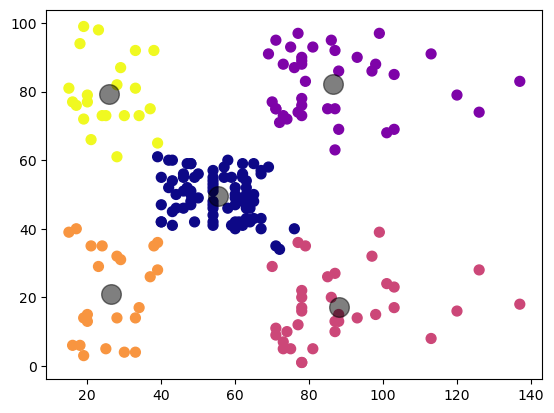

In [14]:
# código

plt.scatter(X.iloc[:,0], X.iloc[:,1],s=50, c=y_kmeans, cmap='plasma')

plt.scatter(centroids[:, 0], centroids[:, 1],s=200, c='black', alpha=0.5);

## Segundo Agrupamento (Idade e Renda) (Cálculo + Plot)

In [15]:
# código
X= df[['Idade', 'Renda']]

In [16]:
# código

kmeans = KMeans(n_clusters=5, random_state=42, n_init="auto").fit(X)
y_kmeans = kmeans.predict(X)
y_kmeans


array([2, 2, 2, 2, 2, 2, 2, 2, 4, 2, 4, 2, 4, 2, 2, 2, 2, 2, 4, 2, 2, 2,
       4, 2, 4, 2, 4, 2, 2, 2, 4, 2, 4, 2, 4, 2, 4, 2, 2, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 2, 2, 4, 2, 2, 4, 4, 4, 4, 0, 2, 0, 0, 2, 0, 0, 0, 2,
       0, 0, 2, 2, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1,
       3, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3], dtype=int32)

In [17]:
centroids = kmeans.cluster_centers_
centroids


array([[ 56.14285714,  57.21428571],
       [ 31.625     ,  72.875     ],
       [ 27.16666667,  29.5952381 ],
       [ 39.        , 106.5       ],
       [ 52.9       ,  33.15      ]])

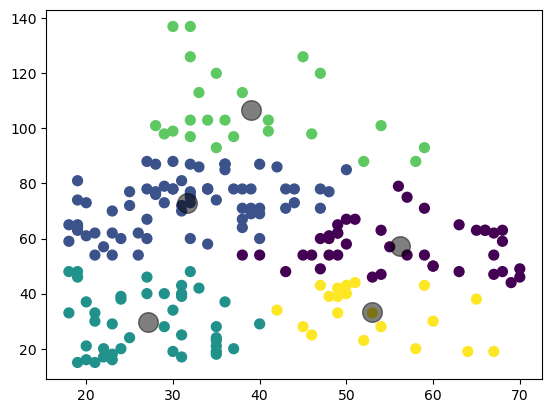

In [18]:
plt.scatter(X.iloc[:,0],X.iloc[:,1], s=50,c=y_kmeans)
plt.scatter(centroids[:,0], centroids[:,1],s=200, c='black', alpha=0.5)

## [Opcional] Terceiro Agrupamento (Idade e Pontuacao Consumo) (Cálculo + Plot)

In [19]:
# código
X = df[['Idade','Pontuacao Consumo']]

In [20]:
# código

kmeans = KMeans(n_clusters=5, random_state=0, n_init="auto").fit(X)
y_kmeans = kmeans.predict(X)
centroids = kmeans.cluster_centers_

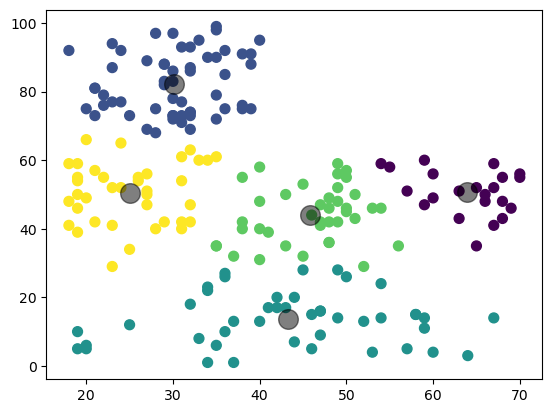

In [21]:
plt.scatter(X.iloc[:,0], X.iloc[:,1], s=50, c=y_kmeans)
plt.scatter(centroids[:,0], centroids[:,1], s=200, c="black", alpha=0.5)